# Práctica: word2vec / Skip-gram

**Autores:** Amai Suárez Navarro y Eduardo Sánchez Belchí 

En este notebook se implementa desde cero (solo con NumPy) el modelo **Skip-gram con muestreo negativo (SGNS)** de word2vec y se entrena sobre el corpus `dataset_word2vec.txt`.

Estructura:

1. Carga y tokenización del corpus
2. Vocabulario y generación de pares *(centro, contexto)* con ventana deslizante
3. Modelo Skip-gram con negative sampling
4. Entrenamiento del modelo base
5. **Entregable 2:** vecinos más cercanos
6. **Entregable 3:** analogías
7. Influencia de los hiperparámetros
8. **Entregable 4:** comentario sobre los hiperparámetros

In [1]:
# ---------------------------------------------------------------
# Librerías
# ---------------------------------------------------------------
import re
import time
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)
SEED = 42  # semilla global para que los resultados sean reproducibles

## 1. Carga y tokenización del corpus

Cada línea del fichero es una oración. La tokenización es sencilla porque el corpus está controlado:
paso a minúsculas y me quedo con secuencias de caracteres alfanuméricos (`\w+`, que en Python 3 incluye letras con tilde y la ñ).

In [ ]:
RUTA_CORPUS = "dataset_word2vec.txt"

def tokenizar(linea):
    # Minúsculas y extracción de palabras; \w admite tildes y ñ (Unicode)
    return re.findall(r"\w+", linea.lower())

with open(RUTA_CORPUS, encoding="utf-8") as f:
    oraciones = [tokenizar(l) for l in f if l.strip()]

n_tokens = sum(len(o) for o in oraciones)
print(f"Oraciones: {len(oraciones)}")
print(f"Tokens:    {n_tokens}")
print("Ejemplos:", oraciones[:3])

Oraciones: 251
Tokens:    1148
Ejemplos: [['el', 'perro', 'corre', 'en', 'el', 'parque'], ['el', 'perro', 'come', 'carne'], ['el', 'perro', 'bebe', 'agua']]


## 2. Vocabulario y pares (centro, contexto)

Construyo el vocabulario (todas las palabras, `min_count = 1`, porque el corpus es muy pequeño) y dos diccionarios para pasar de palabra a índice y viceversa.

Después, para cada palabra *centro* recorro una ventana de tamaño `window` a cada lado y genero un par *(centro, contexto)* por cada vecina. La ventana **no cruza oraciones**.

In [ ]:
frecuencias = Counter(w for o in oraciones for w in o)
# Orden por frecuencia descendente (y alfabético para desempatar, así es determinista)
vocab = sorted(frecuencias, key=lambda w: (-frecuencias[w], w))
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
V = len(vocab)

print(f"Tamaño del vocabulario: {V}")
print("Palabras más frecuentes:", [(w, frecuencias[w]) for w in vocab[:12]])

Tamaño del vocabulario: 356
Palabras más frecuentes: [('la', 131), ('el', 129), ('es', 37), ('está', 27), ('en', 26), ('un', 20), ('por', 15), ('una', 15), ('al', 14), ('gato', 11), ('casa', 10), ('libro', 10)]


In [ ]:
def generar_pares(oraciones, window):
    # Devuelve un array (N, 2) con pares [índice_centro, índice_contexto]
    pares = []
    for o in oraciones:
        ids = [w2i[w] for w in o]
        for i, centro in enumerate(ids):
            ini, fin = max(0, i - window), min(len(ids), i + window + 1)
            for j in range(ini, fin):
                if j != i:
                    pares.append((centro, ids[j]))
    return np.array(pares, dtype=np.int64)

# Ejemplo con la primera oración y ventana 2
ejemplo = generar_pares(oraciones[:1], window=2)
print("Oración:", " ".join(oraciones[0]))
print([(i2w[c], i2w[o]) for c, o in ejemplo])

for w in (1, 2, 4):
    print(f"window={w}: {len(generar_pares(oraciones, w))} pares")

Oración: el perro corre en el parque
[('el', 'perro'), ('el', 'corre'), ('perro', 'el'), ('perro', 'corre'), ('perro', 'en'), ('corre', 'el'), ('corre', 'perro'), ('corre', 'en'), ('corre', 'el'), ('en', 'perro'), ('en', 'corre'), ('en', 'el'), ('en', 'parque'), ('el', 'corre'), ('el', 'en'), ('el', 'parque'), ('parque', 'en'), ('parque', 'el')]
window=1: 1794 pares
window=2: 3086 pares
window=4: 4200 pares


## 3. Modelo Skip-gram con muestreo negativo

El Skip-gram "clásico" usa un softmax sobre todo el vocabulario para predecir el contexto, lo cual es caro. Uso la variante de **muestreo negativo** (Mikolov et al., 2013), que convierte el problema en clasificación binaria:

- Cada palabra tiene dos vectores: $v_w$ (cuando es centro, matriz `W_in`) y $u_w$ (cuando es contexto, matriz `W_out`). Los *embeddings* finales son las filas de `W_in`.
- Para un par real $(c, o)$ y $k$ palabras negativas $n_1..n_k$ muestreadas al azar, la pérdida es

$$
\mathcal{L} = -\log \sigma(u_o^\top v_c) \;-\; \sum_{i=1}^{k} \log \sigma(-u_{n_i}^\top v_c)
$$

- Los negativos se muestrean con la distribución unigrama elevada a 3/4, $P(w) \propto f(w)^{0.75}$, que da algo más de peso a las palabras raras.

Gradientes (con $s_o = \sigma(u_o^\top v_c)$ y $s_{n} = \sigma(u_n^\top v_c)$):

$$
\frac{\partial \mathcal{L}}{\partial v_c} = (s_o - 1)\,u_o + \sum_i s_{n_i} u_{n_i}, \qquad
\frac{\partial \mathcal{L}}{\partial u_o} = (s_o - 1)\,v_c, \qquad
\frac{\partial \mathcal{L}}{\partial u_{n_i}} = s_{n_i}\,v_c
$$

El entrenamiento es SGD por mini-lotes con tasa de aprendizaje que decae linealmente, como en la implementación original.

In [ ]:
def sigmoide(x):
    # Se recorta el argumento para evitar overflow en exp
    return 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))


class SkipGramNS:
    # Skip-gram con negative sampling implementado con NumPy.

    def __init__(self, dim=50, window=2, negative=5, epochs=200, lr=0.05,
                 batch_size=64, seed=SEED):
        self.dim, self.window, self.negative = dim, window, negative
        self.epochs, self.lr, self.batch_size, self.seed = epochs, lr, batch_size, seed

    def fit(self, oraciones, verbose=False):
        rng = np.random.default_rng(self.seed)
        pares = generar_pares(oraciones, self.window)

        # Inicialización: W_in pequeña y aleatoria, W_out a cero (como en word2vec)
        self.W_in = (rng.random((V, self.dim)) - 0.5) / self.dim
        self.W_out = np.zeros((V, self.dim))

        # Distribución de muestreo de negativos: frecuencia^0.75 normalizada
        p_neg = np.array([frecuencias[w] for w in vocab], dtype=float) ** 0.75
        p_neg /= p_neg.sum()

        self.historial_loss = []
        for epoca in range(self.epochs):
            rng.shuffle(pares)
            # Decaimiento lineal de la tasa de aprendizaje
            lr = self.lr * (1 - epoca / self.epochs) + 1e-4
            loss_total = 0.0

            for b in range(0, len(pares), self.batch_size):
                c = pares[b:b + self.batch_size, 0]          # índices centro   (B,)
                o = pares[b:b + self.batch_size, 1]          # índices contexto (B,)
                neg = rng.choice(V, size=(len(c), self.negative), p=p_neg)  # (B, k)

                v_c = self.W_in[c]                           # (B, d)
                u_o = self.W_out[o]                          # (B, d)
                u_n = self.W_out[neg]                        # (B, k, d)

                # Probabilidades del par positivo y de los negativos
                s_o = sigmoide(np.sum(v_c * u_o, axis=1))                 # (B,)
                s_n = sigmoide(np.einsum("bd,bkd->bk", v_c, u_n))         # (B, k)

                loss_total += -(np.log(s_o + 1e-9).sum() + np.log(1 - s_n + 1e-9).sum())

                # Gradientes (ver fórmulas de la celda anterior)
                g_o = (s_o - 1)[:, None]                     # (B, 1)
                g_n = s_n[:, :, None]                        # (B, k, 1)
                grad_vc = g_o * u_o + np.sum(g_n * u_n, axis=1)

                # np.add.at acumula correctamente cuando un índice se repite en el lote
                np.add.at(self.W_out, o, -lr * g_o * v_c)
                np.add.at(self.W_out, neg, -lr * g_n * v_c[:, None, :])
                np.add.at(self.W_in, c, -lr * grad_vc)

            self.historial_loss.append(loss_total / len(pares))
            if verbose and (epoca % max(1, self.epochs // 10) == 0 or epoca == self.epochs - 1):
                print(f"época {epoca:4d} | lr {lr:.4f} | loss {self.historial_loss[-1]:.4f}")

        # Embeddings normalizados (norma 1) para calcular similitud coseno con un producto escalar
        self.E = self.W_in / np.linalg.norm(self.W_in, axis=1, keepdims=True)
        return self

    # ------------------------- consultas -------------------------
    def similitud(self, a, b):
        return float(self.E[w2i[a]] @ self.E[w2i[b]])

    def vecinos(self, palabra, k=8):
        # Las k palabras con mayor similitud coseno (excluida la propia palabra)
        sims = self.E @ self.E[w2i[palabra]]
        orden = [i for i in np.argsort(-sims) if i != w2i[palabra]][:k]
        return [(i2w[i], float(sims[i])) for i in orden]

    def analogia(self, a, b, c, k=5):
        # a : b :: c : ?   ->   vector(b) - vector(a) + vector(c)   (método 3CosAdd)
        q = self.E[w2i[b]] - self.E[w2i[a]] + self.E[w2i[c]]
        q /= np.linalg.norm(q)
        sims = self.E @ q
        excluir = {w2i[a], w2i[b], w2i[c]}
        orden = [i for i in np.argsort(-sims) if i not in excluir][:k]
        return [(i2w[i], float(sims[i])) for i in orden]

## 4. Entrenamiento del modelo base

Hiperparámetros de partida: dimensión 50, ventana 2, 5 negativos, 200 épocas, lr inicial 0.05.
Con tan pocos datos (≈1.100 tokens) hacen falta muchas épocas para que los vectores converjan.

época    0 | lr 0.0501 | loss 4.1455
época   20 | lr 0.0451 | loss 1.8609
época   40 | lr 0.0401 | loss 1.4146
época   60 | lr 0.0351 | loss 1.2833
época   80 | lr 0.0301 | loss 1.2344
época  100 | lr 0.0251 | loss 1.2217
época  120 | lr 0.0201 | loss 1.1782
época  140 | lr 0.0151 | loss 1.1658
época  160 | lr 0.0101 | loss 1.1240
época  180 | lr 0.0051 | loss 1.1140
época  199 | lr 0.0004 | loss 1.0979

Tiempo de entrenamiento: 24.7 s


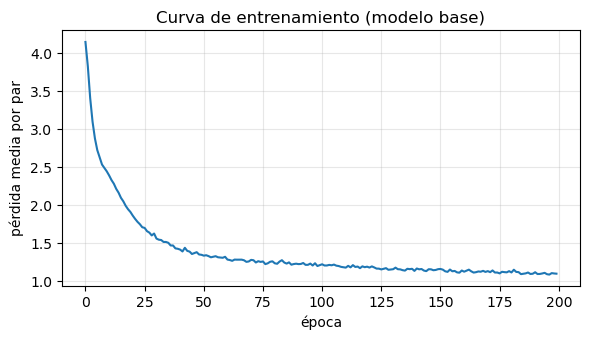

In [6]:
PARAMS_BASE = dict(dim=50, window=2, negative=5, epochs=200, lr=0.05)

t0 = time.time()
modelo = SkipGramNS(**PARAMS_BASE).fit(oraciones, verbose=True)
print(f"\nTiempo de entrenamiento: {time.time() - t0:.1f} s")

plt.figure(figsize=(6, 3.5))
plt.plot(modelo.historial_loss)
plt.xlabel("época"); plt.ylabel("pérdida media por par")
plt.title("Curva de entrenamiento (modelo base)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Vecinos más cercanos (Entregable 2)

Para cada palabra de consulta muestro sus 6 vecinos más cercanos por similitud coseno.

In [7]:
CONSULTAS = ["perro", "gata", "coche", "parís", "francia", "rey", "médico", "café", "padre", "lunes"]

def tabla_vecinos(modelo, palabras, k=6):
    filas = {}
    for p in palabras:
        filas[p] = [f"{w} ({s:.2f})" for w, s in modelo.vecinos(p, k)]
    return pd.DataFrame.from_dict(filas, orient="index",
                                  columns=[f"vecino {i+1}" for i in range(k)])

tabla = tabla_vecinos(modelo, CONSULTAS)
tabla.to_csv("vecinos_modelo_base.csv")
tabla

,vecino 1,vecino 2,vecino 3,vecino 4,vecino 5,vecino 6
perro,gato (0.78),ladra (0.75),perra (0.73),hermano (0.70),fuerte (0.69),ratón (0.69)
gata,perra (0.85),gato (0.71),cuerda (0.70),hermana (0.70),cacao (0.70),entro (0.69)
coche,conductor (0.84),pintor (0.80),cuadro (0.78),verano (0.77),invierno (0.75),lento (0.75)
parís,madrid (1.00),roma (1.00),francia (0.89),españa (0.89),italia (0.88),ciudad (0.82)
francia,italia (1.00),españa (1.00),parís (0.89),palacio (0.89),roma (0.88),madrid (0.88)
rey,reina (0.79),suelo (0.75),cuaderno (0.75),patio (0.74),campo (0.74),sofá (0.74)
médico,enfermero (0.98),bebé (0.85),ellas (0.80),alumno (0.77),escucha (0.76),maestro (0.76)
café,té (0.94),camarero (0.79),ruido (0.76),humo (0.75),helado (0.75),chocolate (0.74)
padre,revista (0.84),periódico (0.82),madre (0.82),correr (0.81),leer (0.80),niño (0.80)
lunes,sábados (1.00),martes (0.99),mercado (0.95),museo (0.89),pantalones (0.88),son (0.87)


Visualización en 2D (PCA sobre los embeddings) de algunos grupos de palabras para ver si se agrupan por significado:

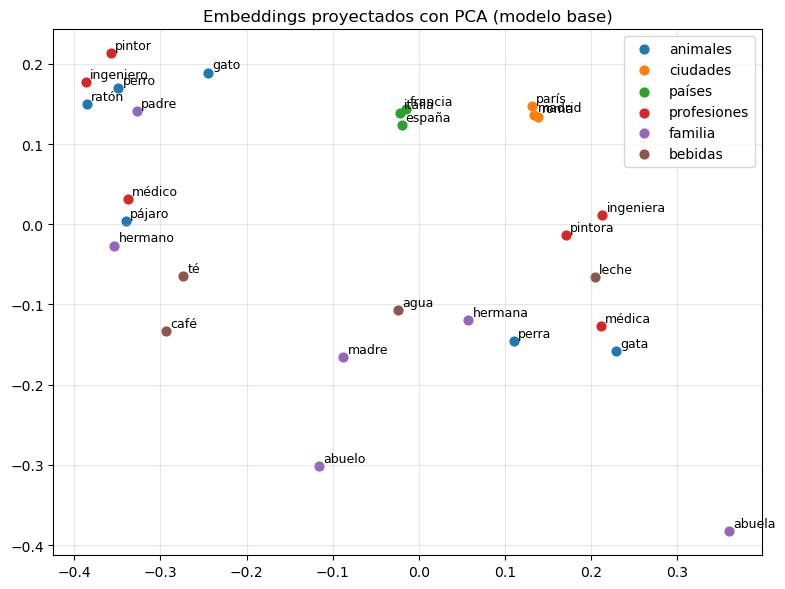

In [8]:
grupos = {
    "animales":   ["perro", "perra", "gato", "gata", "pájaro", "ratón"],
    "ciudades":   ["parís", "madrid", "roma"],
    "países":     ["francia", "españa", "italia"],
    "profesiones":["médico", "médica", "ingeniero", "ingeniera", "pintor", "pintora"],
    "familia":    ["padre", "madre", "hermano", "hermana", "abuelo", "abuela"],
    "bebidas":    ["agua", "leche", "café", "té"],
}

# PCA "a mano": centrar y proyectar sobre los 2 primeros vectores singulares
X = modelo.E - modelo.E.mean(axis=0)
_, _, Vt = np.linalg.svd(X, full_matrices=False)
proy = X @ Vt[:2].T

plt.figure(figsize=(8, 6))
for nombre, palabras in grupos.items():
    pts = np.array([proy[w2i[w]] for w in palabras])
    plt.scatter(pts[:, 0], pts[:, 1], label=nombre, s=40)
    for w, (x, y) in zip(palabras, pts):
        plt.annotate(w, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=9)
plt.legend(); plt.title("Embeddings proyectados con PCA (modelo base)")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("pca_embeddings.png", dpi=150); plt.show()

**Observaciones.** Las ciudades (parís, madrid, roma) y los países (francia, españa, italia) forman grupos muy compactos. Lo más llamativo es que **el primer eje de la PCA separa masculino y femenino**: perro, gato, padre, ingeniero, pintor y médico quedan a la izquierda, y perra, gata, ingeniera, pintora y médica a la derecha. El modelo ha aprendido el género porque en el corpus casi siempre lo marca el artículo (*el* / *la*) que tiene justo al lado.

En la tabla de vecinos también aparecen palabras que no son sinónimos pero comparten contexto (perro → *ladra*, coche → *conductor*, café → *camarero*): Skip-gram mide **similitud distribucional**, no solo semántica en sentido estricto. Con un corpus de unas 1.100 palabras también aparece ruido (gata → *cacao*, rey → *suelo*), porque muchas palabras solo salen una o dos veces.

## 6. Analogías (Entregable 3)

Para resolver `a : b :: c : ?` calculo $\vec{b} - \vec{a} + \vec{c}$ y busco la palabra más cercana, excluyendo $a$, $b$ y $c$ (método 3CosAdd).

In [9]:
ANALOGIAS = [
    ("parís", "francia", "madrid"),   # esperado: españa
    ("parís", "francia", "roma"),     # esperado: italia
    ("madrid", "españa", "parís"),    # esperado: francia
    ("perro", "perra", "gato"),       # esperado: gata
    ("rey", "reina", "padre"),        # esperado: madre
    ("niño", "niña", "médico"),       # esperado: médica
    ("hermano", "hermana", "abuelo"), # esperado: abuela
    ("ingeniero", "ingeniera", "programador"),  # esperado: programadora
]
ESPERADO = ["españa", "italia", "francia", "gata", "madre", "médica", "abuela", "programadora"]

filas = []
for (a, b, c), esp in zip(ANALOGIAS, ESPERADO):
    res = modelo.analogia(a, b, c, k=3)
    filas.append({
        "analogía": f"{a} : {b} :: {c} : ?",
        "esperado": esp,
        "top-3": ", ".join(f"{w} ({s:.2f})" for w, s in res),
        "acierto top-1": "✔" if res[0][0] == esp else "✘",
        "en top-3": "✔" if esp in [w for w, _ in res] else "✘",
    })
tabla_analogias = pd.DataFrame(filas)
tabla_analogias.to_csv("analogias_modelo_base.csv", index=False)
tabla_analogias

,analogía,esperado,top-3,acierto top-1,en top-3
0,parís : francia :: madrid : ?,españa,"españa (1.00), italia (1.00), roma (0.89)",✔,✔
1,parís : francia :: roma : ?,italia,"españa (1.00), italia (1.00), madrid (0.89)",✘,✔
2,madrid : españa :: parís : ?,francia,"italia (1.00), francia (1.00), palacio (0.88)",✘,✔
3,perro : perra :: gato : ?,gata,"gata (0.96), hermana (0.66), cacao (0.66)",✔,✔
4,rey : reina :: padre : ?,madre,"madre (0.85), revista (0.84), niña (0.78)",✔,✔
5,niño : niña :: médico : ?,médica,"enfermera (0.95), médica (0.90), ayuda (0.83)",✘,✔
6,hermano : hermana :: abuelo : ?,abuela,"abuela (0.97), pasea (0.89), trabajas (0.83)",✔,✔
7,ingeniero : ingeniera :: programador : ?,programadora,"programadora (0.97), alumna (0.83), código (0.80)",✔,✔


**Observaciones.** Las analogías de género funcionan muy bien (perro:perra::gato:**gata**, rey:reina::padre:**madre**, ingeniero:ingeniera::programador:**programadora**). En niño:niña::médico:? la respuesta correcta, *médica*, sale segunda tras *enfermera*, que comparte contexto con médica ("la enfermera ayuda a la médica").

Las analogías capital–país son un caso especial: *españa* e *italia* empatan prácticamente a 1.00. Esto no es un fallo del modelo sino del corpus: parís, madrid y roma aparecen en frases idénticas ("X es una ciudad") salvo **una única** frase cada una ("X está en Y"), así que el modelo apenas tiene información para distinguir qué país va con qué capital. Siempre acierta que la respuesta es *un país* (top-3 = 100 %), pero elegir el país concreto es casi una moneda al aire.

## 7. Influencia de los hiperparámetros

Para comparar configuraciones de forma objetiva defino dos métricas:

- **Precisión en analogías:** construyo automáticamente un banco de analogías a partir de las parejas masculino/femenino del corpus (`perro/perra`, `médico/médica`, `rey/reina`...) y de las parejas capital/país. Mido el % de aciertos en top-1 y en top-5.
- **Separación semántica:** similitud coseno media entre parejas que *deberían* parecerse (las anteriores) menos la similitud media entre parejas aleatorias. Cuanto mayor, mejor separa el modelo lo relacionado de lo no relacionado.

Cada configuración se entrena con **3 semillas** y promedio, porque con un corpus tan pequeño los resultados varían bastante de una ejecución a otra. Cambio un hiperparámetro cada vez dejando el resto como en el modelo base.

In [10]:
# Parejas de género presentes en el corpus
PAREJAS_GENERO = [
    ("perro", "perra"), ("gato", "gata"), ("niño", "niña"), ("padre", "madre"),
    ("rey", "reina"), ("hermano", "hermana"), ("abuelo", "abuela"), ("amigo", "amiga"),
    ("maestro", "maestra"), ("alumno", "alumna"), ("médico", "médica"),
    ("enfermero", "enfermera"), ("panadero", "panadera"), ("cocinero", "cocinera"),
    ("camarero", "camarera"), ("conductor", "conductora"), ("ingeniero", "ingeniera"),
    ("programador", "programadora"), ("pintor", "pintora"), ("jardinero", "jardinera"),
    ("bombero", "bombera"), ("profesor", "profesora"), ("nosotros", "nosotras"),
    ("vosotros", "vosotras"), ("ellos", "ellas"),
]
PAREJAS_CAPITAL = [("parís", "francia"), ("madrid", "españa"), ("roma", "italia")]
assert all(w in w2i for p in PAREJAS_GENERO + PAREJAS_CAPITAL for w in p)

def banco_analogias(parejas):
    # Todas las combinaciones (a, b, c, d) con a:b y c:d parejas distintas
    return [(a, b, c, d) for (a, b), (c, d) in itertools.permutations(parejas, 2)]

BANCO_GENERO = banco_analogias(PAREJAS_GENERO)
BANCO_CAPITAL = banco_analogias(PAREJAS_CAPITAL)
print(f"Analogías de género: {len(BANCO_GENERO)} | capital-país: {len(BANCO_CAPITAL)}")

def precision_analogias(m, banco, k=5):
    top1 = topk = 0
    for a, b, c, d in banco:
        pred = [w for w, _ in m.analogia(a, b, c, k=k)]
        top1 += pred[0] == d
        topk += d in pred
    return 100 * top1 / len(banco), 100 * topk / len(banco)

rng_eval = np.random.default_rng(0)
PAREJAS_ALEATORIAS = [tuple(rng_eval.choice(vocab, 2, replace=False)) for _ in range(300)]

def separacion(m):
    rel = np.mean([m.similitud(a, b) for a, b in PAREJAS_GENERO + PAREJAS_CAPITAL])
    ale = np.mean([m.similitud(a, b) for a, b in PAREJAS_ALEATORIAS])
    return rel - ale

def evaluar(params, semillas=(0, 1, 2)):
    res = []
    for s in semillas:
        m = SkipGramNS(**params, seed=s).fit(oraciones)
        g1, g5 = precision_analogias(m, BANCO_GENERO)
        c1, c5 = precision_analogias(m, BANCO_CAPITAL)
        res.append((g1, g5, c1, c5, separacion(m), m.historial_loss[-1]))
    return np.mean(res, axis=0)

Analogías de género: 600 | capital-país: 6


In [ ]:
EXPERIMENTOS = {
    "window":   [1, 2, 4, 6],
    "dim":      [5, 10, 50, 100],
    "negative": [1, 5, 15],
    "epochs":   [10, 50, 200, 400],
    "lr":       [0.005, 0.05, 0.2],
}

resultados = []
t0 = time.time()
for hp, valores in EXPERIMENTOS.items():
    for val in valores:
        params = {**PARAMS_BASE, hp: val}
        g1, g5, c1, c5, sep, loss = evaluar(params)
        resultados.append({"hiperparámetro": hp, "valor": val,
                           "género top-1 %": g1, "género top-5 %": g5,
                           "capital top-1 %": c1, "capital top-5 %": c5,
                           "separación": sep, "loss final": loss})
        print(f"{hp:>8} = {val:<6} | género top1 {g1:5.1f}%  top5 {g5:5.1f}% | "
              f"capital top1 {c1:5.1f}% | separación {sep:.3f}")
print(f"\nTiempo total: {time.time() - t0:.0f} s")

df_hp = pd.DataFrame(resultados)
df_hp["valor"] = df_hp["valor"].map(lambda v: f"{v:g}")  # evita que lr=0.005 se muestre como 0.00
df_hp.to_csv("barrido_hiperparametros.csv", index=False)
df_hp.round(1)

  window = 1      | género top1  67.0%  top5  86.6% | capital top1  44.4% | separación 0.333
  window = 2      | género top1  63.2%  top5  79.3% | capital top1  61.1% | separación 0.390
  window = 4      | género top1  45.0%  top5  80.7% | capital top1  72.2% | separación 0.428
  window = 6      | género top1  46.4%  top5  81.3% | capital top1  66.7% | separación 0.425
     dim = 5      | género top1  10.3%  top5  25.3% | capital top1  61.1% | separación 0.380
     dim = 10     | género top1  34.9%  top5  60.3% | capital top1  55.6% | separación 0.384
     dim = 50     | género top1  63.2%  top5  79.3% | capital top1  61.1% | separación 0.390


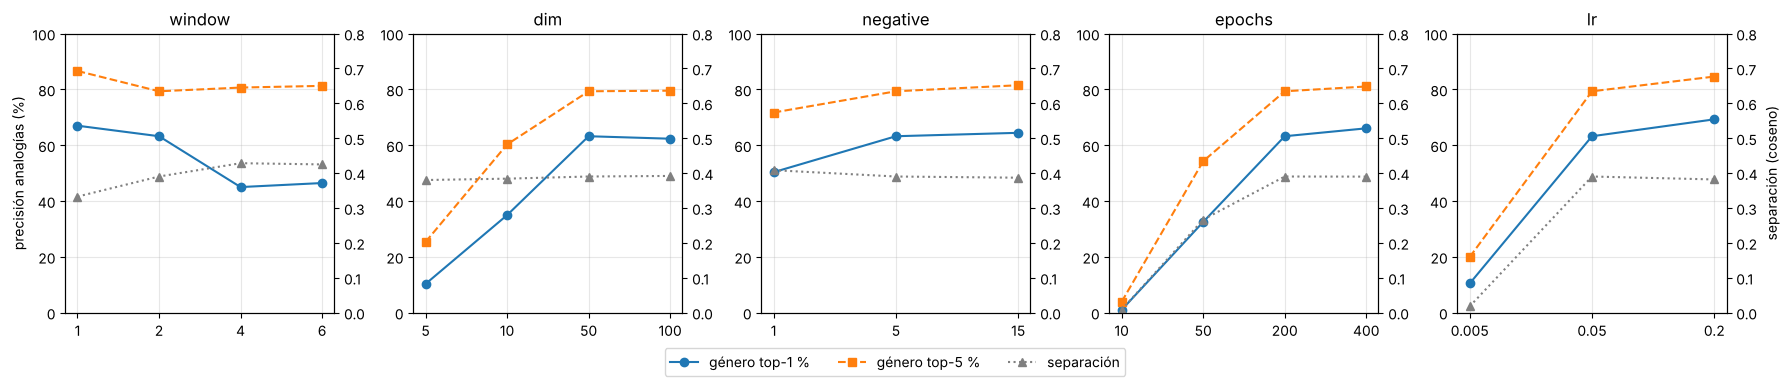

In [ ]:
# Gráficas: una por hiperparámetro, con precisión de analogías (género) y separación
fig, ejes = plt.subplots(1, len(EXPERIMENTOS), figsize=(18, 3.6))
for ax, hp in zip(ejes, EXPERIMENTOS):
    d = df_hp[df_hp["hiperparámetro"] == hp]
    x = list(d["valor"])
    ax.plot(x, d["género top-1 %"], "o-", label="género top-1 %")
    ax.plot(x, d["género top-5 %"], "s--", label="género top-5 %")
    ax.set_title(hp); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(x, d["separación"], "^:", color="gray", label="separación")
    ax2.set_ylim(0, max(0.8, df_hp["separación"].max() * 1.1))
    if hp == list(EXPERIMENTOS)[-1]:
        ax2.set_ylabel("separación (coseno)")
ejes[0].set_ylabel("precisión analogías (%)")
h1, l1 = ejes[0].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout(); plt.savefig("barrido_hiperparametros.png", dpi=150, bbox_inches="tight"); plt.show()

Efecto cualitativo de la ventana: vecinos de las mismas palabras con `window = 1` y `window = 4`.

In [ ]:
for w in (1, 4):
    m = SkipGramNS(**{**PARAMS_BASE, "window": w}).fit(oraciones)
    print(f"\n=== window = {w} ===")
    for p in ["perro", "coche", "parís"]:
        print(f"{p:>7}: " + ", ".join(f"{v} ({s:.2f})" for v, s in m.vecinos(p, 6)))


=== window = 1 ===
  perro: fuerte (0.91), gato (0.82), hermano (0.75), gata (0.74), perra (0.73), coche (0.73)
  coche: profesor (0.96), verano (0.96), invierno (0.95), libro (0.88), chocolate (0.87), árbol (0.86)
  parís: madrid (1.00), roma (1.00), amarilla (0.88), curioso (0.88), curiosa (0.88), gris (0.88)



=== window = 4 ===
  perro: perra (0.79), ladra (0.65), ratón (0.65), fuerte (0.64), gato (0.62), suelo (0.61)
  coche: conductora (0.74), espera (0.71), pasa (0.69), maneja (0.67), conductor (0.65), cuadro (0.65)
  parís: madrid (0.99), roma (0.99), españa (0.82), francia (0.81), italia (0.79), país (0.74)


## 8. Comentario sobre los hiperparámetros (Entregable 4)

Resumen del barrido (media de 3 semillas, cambiando un hiperparámetro cada vez):

| Hiperparámetro | Efecto observado |
|---|---|
| **Épocas** | El más determinante. Con 10 épocas el modelo no aprende nada (separación ≈ 0, 1 % de analogías); con 50 llega al ~33 %; a partir de 200 se estabiliza (~63–66 %). |
| **Tasa de aprendizaje** | Igual de crítica: con 0.005 el modelo apenas se mueve en 200 épocas (10 % de analogías). Entre 0.05 y 0.2 los resultados son parecidos. |
| **Dimensión** | Con 5 o 10 dimensiones faltan "ejes" para codificar a la vez género, categoría y función de la palabra (10 % y 35 %). De 50 a 100 ya no mejora. |
| **Ventana** | No cambia tanto *cuánto* aprende, sino *qué* tipo de similitud captura (ver abajo). |
| **Negativos** | 1 negativo es claramente peor (50 %); entre 5 y 15 casi no hay diferencia. |

**Por qué épocas y lr son lo más importante.** El corpus tiene solo ~1.100 tokens y la mayoría de palabras aparecen 1–3 veces (*perro* aparece 10 veces). Cada actualización mueve un vector un poco, así que el desplazamiento total depende del producto *lr × nº de pasadas*. Si es pequeño, los vectores se quedan cerca de su inicialización aleatoria y todo parece igual de similar (por eso la separación cae a ≈ 0). Con corpus grandes una sola época suele bastar porque cada palabra aparece miles de veces; aquí hay que compensar la falta de datos con muchas pasadas.

**Por qué la dimensión deja de importar a partir de 50.** Con un vocabulario de 356 palabras y relaciones bastante simples no hace falta más capacidad. Por debajo de 10 dimensiones, en cambio, las palabras tienen que "compartir" ejes y se mezclan relaciones distintas.

**La ventana define el tipo de similitud.**
- **Ventana pequeña (1):** captura similitud *sintáctica/funcional*: palabras que ocupan la misma posición en la frase. Es la mejor para analogías de género (67 % top-1) porque el género lo marca el artículo *el/la* inmediatamente adyacente. Pero produce vecinos poco intuitivos: *parís* queda cerca de *curioso* o *gris*, porque todas van junto a *es*.
- **Ventana grande (4–6):** captura similitud *temática*: *coche* pasa a tener como vecinos *conductora* y *maneja*, y *perro* tiene a *perra* en primer lugar. Las analogías capital–país mejoran (72 %), porque cada capital "ve" a su país en la frase "X está en Y" aunque esté a 3 palabras. A cambio el género se diluye, porque el artículo pesa menos entre muchas palabras de contexto (45 %).

**Negativos.** Con un solo negativo por par, el modelo recibe muy poca señal de qué palabras *no* deben parecerse, así que empuja menos a separarlas. A partir de 5 ya hay señal suficiente para un vocabulario de este tamaño. (Ojo: la pérdida no es comparable entre valores distintos de `negative`, porque cambia el número de términos que se suman.)

**Otras observaciones.**
- La **pérdida final no es buena guía** para elegir hiperparámetros: `window=1` y `negative=1` tienen la pérdida más baja y no son las mejores configuraciones. Lo que importa es la calidad de los vectores, que hay que medir con tareas como analogías o similitud.
- Con un corpus tan pequeño **la varianza entre semillas es alta**; por eso promedio 3 ejecuciones. Diferencias de unos pocos puntos (p. ej. 63 % vs 66 %) no son significativas.
- Las palabras *el* y *la* suman ~23 % de los tokens y aparecen en casi todas las ventanas. Word2vec original usa *subsampling* de palabras frecuentes para reducir este efecto; aquí no lo he aplicado porque precisamente el artículo es lo que permite aprender el género.

**Conclusión:** en este corpus, lo que más influye es entrenar lo suficiente (épocas y lr), seguido de tener al menos ~50 dimensiones. La ventana es el hiperparámetro más interesante, porque elige entre similitud gramatical (ventana pequeña) y temática (ventana grande).